In [1]:

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


In [2]:
df = pd.read_csv("../data/heart_disease_cleaned.csv")  # use cleaned dataset saved from Notebook 1


In [3]:
X = df.drop(columns=["target"])
y = df["target"]


In [4]:
pca = PCA()
X_pca = pca.fit_transform(X)

# Explained variance ratio
explained_variance = pca.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()


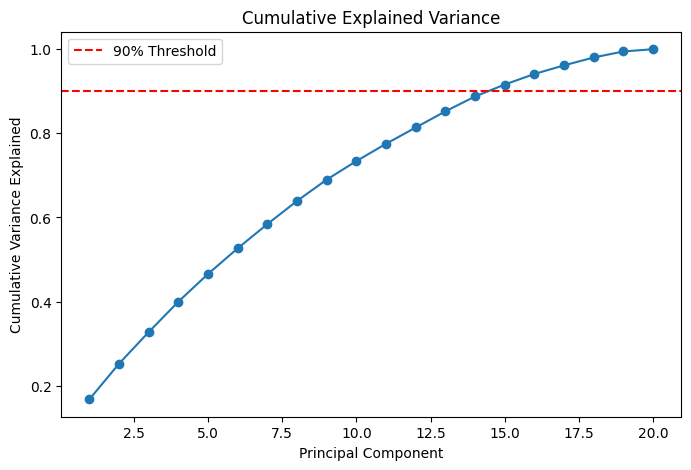

In [5]:
# Plot cumulative variance

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker="o")
plt.xlabel("Principal Component")
plt.ylabel("Cumulative Variance Explained")
plt.title("Cumulative Explained Variance")
plt.axhline(y=0.9, color="r", linestyle="--", label="90% Threshold")
plt.legend()
plt.show()

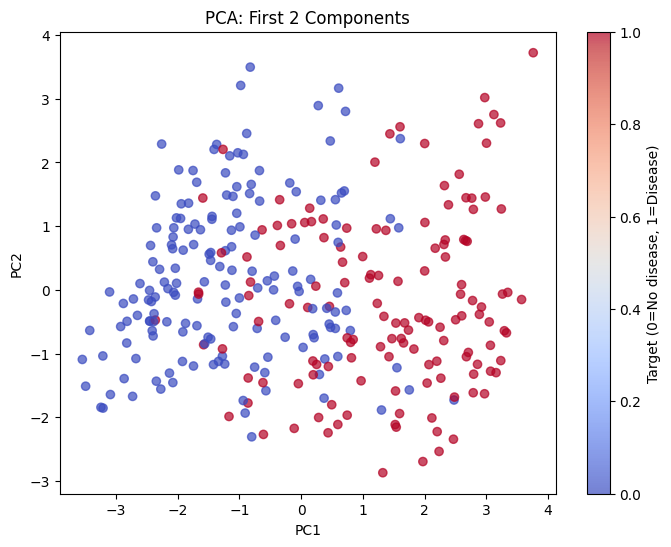

In [6]:
# Scatter plot of first 2 PCs
# -----------------------------
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap="coolwarm", alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA: First 2 Components")
plt.colorbar(label="Target (0=No disease, 1=Disease)")
plt.show()


In [7]:
# Decide number of components
# -----------------------------
n_components_90 = (cumulative_variance >= 0.9).argmax() + 1
print(f"Number of components needed to retain 90% variance: {n_components_90}")


Number of components needed to retain 90% variance: 15
